In [2]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data[:, :2]
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=39, test_size=0.3)


df = pd.DataFrame(X, columns=data.feature_names[:2])
df["diagnosis"] = data.target

In [3]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


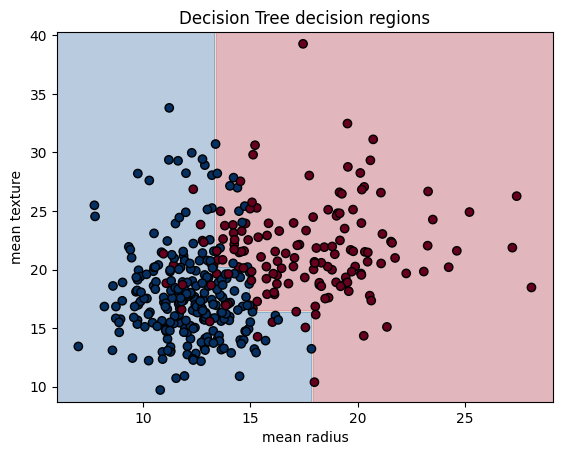

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# make grid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# plot original points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Decision Tree decision regions")
plt.show()


In [5]:
y_pred = model.predict(X_test)
y_pred

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8830409356725146


In [6]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5) 
print("CV accuracy:", scores.mean())

CV accuracy: 0.8840242198416395


In [7]:
print(confusion_matrix(y_test, y_pred))


[[53 10]
 [10 98]]


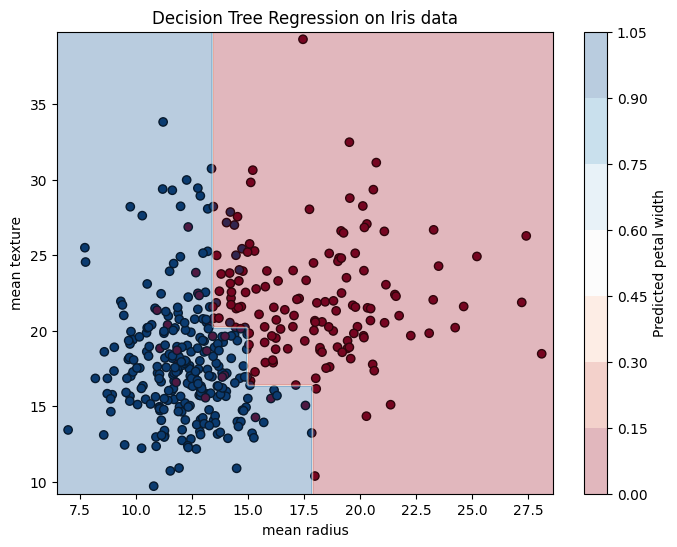

In [16]:
# Create a grid of test points (like X_test before)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu)
plt.xlabel(data.feature_names[0])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

plt.ylabel(data.feature_names[1])
plt.title("Decision Tree Regression on Iris data")
plt.colorbar(label="Predicted petal width")
plt.show()
